# Análisis de Brecha Salarial y Estructura de Remuneraciones

**Autor:** Agustina de Oro  
**Curso:** Curso de Herramientas Básicas para el Análisis de Datos  
**Cohorte:** 2026

## Objetivo del análisis

El objetivo de este análisis es explorar la relación entre el salario y distintas características de las personas incluidas en el dataset, especialmente el género, el nivel educativo y los años de experiencia laboral.

A partir de los datos se busca identificar diferencias salariales y observar qué variables presentan una mayor relación con el salario.

## Preguntas que guían el análisis

1. ¿Existe una diferencia entre el salario promedio de varones y mujeres?
2. ¿Cómo se comportan los salarios según el nivel educativo y el género?
3. ¿Existe una relación entre los años de experiencia y el salario?
4. ¿Qué relación presentan las variables numéricas entre sí?
5. ¿Qué conclusiones pueden obtenerse de los datos analizados?

Estas preguntas permiten orientar los gráficos y evitar que el análisis se limite únicamente a la descripción visual de los datos.

## 1. Carga de datos

Se importa el dataset original para comenzar con la exploración y preparación de la información.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Salary Data.csv')

print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")
df.head()

Cantidad de filas: 375
Cantidad de columnas: 6


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Auditoría inicial de los datos

Antes de realizar la limpieza se revisan los nombres de las columnas, los tipos de datos, los valores faltantes y los registros duplicados.

Esta auditoría permite conocer la estructura del dataset y detectar problemas que puedan afectar el análisis posterior.

In [3]:
print("=== NOMBRES DE COLUMNAS ===")
print(df.columns.tolist())

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())

print("\n=== REGISTROS DUPLICADOS ===")
print(df.duplicated().sum())

=== NOMBRES DE COLUMNAS ===
['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience', 'Salary']

=== TIPOS DE DATOS ===
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

=== VALORES NULOS POR COLUMNA ===
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

=== REGISTROS DUPLICADOS ===
50


## 3. Limpieza y preparación de los datos

Se realizan las siguientes transformaciones:

En la auditoría inicial se identificaron 2 valores faltantes en cada una de las 6 variables analizadas, totalizando 12 valores nulos. Debido a que representan una cantidad reducida respecto del total de registros, se decidió eliminar las observaciones incompletas.

In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

filas_antes = len(df)
nulos_antes = df.isnull().sum().sum()
duplicados_antes = df.duplicated().sum()

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(f"Filas antes de la limpieza: {filas_antes}")
print(f"Valores nulos eliminados: {nulos_antes}")
print(f"Duplicados eliminados: {duplicados_antes}")
print(f"Filas después de la limpieza: {len(df)}")

Filas antes de la limpieza: 375
Valores nulos eliminados: 12
Duplicados eliminados: 50
Filas después de la limpieza: 324


## 4. Renombrado y estandarización de variables

Se traducen algunos nombres de variables al español para facilitar la lectura del análisis. También se estandarizan los valores de la variable género.

La transformación no modifica el significado de los datos; solamente mejora su claridad y consistencia para el análisis.

In [5]:
columnas_map = {
    'gender': 'genero',
    'education_level': 'nivel_educativo',
    'years_of_experience': 'experiencia_anios',
    'salary': 'salario'
}

df.rename(
    columns={k: v for k, v in columnas_map.items() if k in df.columns},
    inplace=True
)

if 'genero' in df.columns:
    df['genero'] = df['genero'].replace({
        'Male': 'Varón',
        'Female': 'Mujer'
    })

print("Columnas finales:")
print(df.columns.tolist())

print("\nValores de género:")
print(df['genero'].value_counts())

Columnas finales:
['age', 'genero', 'nivel_educativo', 'job_title', 'experiencia_anios', 'salario']

Valores de género:
genero
Varón    170
Mujer    154
Name: count, dtype: int64


## 5. Tratamiento de valores extremos

Para identificar posibles valores atípicos en el salario se utiliza el método del rango intercuartílico (IQR).

Se consideran valores extremos aquellos que se encuentran por debajo de Q1 - 1,5 × IQR o por encima de Q3 + 1,5 × IQR.

La decisión de excluir estos valores busca evitar que observaciones salariales extremadamente alejadas del resto distorsionen los promedios y las visualizaciones. Esta decisión se aplica únicamente a la variable salario.

In [6]:
Q1 = df['salario'].quantile(0.25)
Q3 = df['salario'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

df_limpio = df[
    (df['salario'] >= limite_inferior) &
    (df['salario'] <= limite_superior)
].copy()

print(f"Q1: ${Q1:,.2f}")
print(f"Q3: ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Límite inferior: ${limite_inferior:,.2f}")
print(f"Límite superior: ${limite_superior:,.2f}")
print(f"Registros antes del tratamiento de outliers: {len(df)}")
print(f"Registros después del tratamiento de outliers: {len(df_limpio)}")
print(f"Registros excluidos: {len(df) - len(df_limpio)}")

Q1: $55,000.00
Q3: $140,000.00
IQR: $85,000.00
Límite inferior: $-72,500.00
Límite superior: $267,500.00
Registros antes del tratamiento de outliers: 324
Registros después del tratamiento de outliers: 324
Registros excluidos: 0


## 6. Cálculo del salario promedio y de la brecha salarial

Se calcula el salario promedio para varones y mujeres utilizando el dataset luego de la limpieza.

La brecha salarial porcentual se calcula tomando como referencia el salario promedio de los varones:

**Brecha (%) = (Salario promedio varones - Salario promedio mujeres) / Salario promedio varones × 100**

Este indicador permite cuantificar la diferencia observada en los salarios promedio. No debe interpretarse por sí solo como una explicación causal de la diferencia, ya que pueden intervenir otras variables, como experiencia, educación u ocupación.

In [7]:
prom_varon = df_limpio[df_limpio['genero'] == 'Varón']['salario'].mean()
prom_mujer = df_limpio[df_limpio['genero'] == 'Mujer']['salario'].mean()
brecha_pct = ((prom_varon - prom_mujer) / prom_varon) * 100

print("=== RESULTADOS CALCULADOS ===")
print(f"Salario promedio varones: ${prom_varon:,.2f}")
print(f"Salario promedio mujeres: ${prom_mujer:,.2f}")
print(f"Brecha salarial observada: {brecha_pct:.2f}%")

=== RESULTADOS CALCULADOS ===
Salario promedio varones: $103,472.65
Salario promedio mujeres: $96,136.36
Brecha salarial observada: 7.09%


## 7. Análisis visual

A continuación se presentan cuatro gráficos. Cada uno responde a una de las preguntas planteadas al comienzo del notebook.

### 7.1 Distribución salarial por género

**Pregunta:** ¿Cómo se distribuyen los salarios de varones y mujeres?

Se observa que la curva salarial de los varones está ligeramente desplazada hacia la derecha en comparación con la de las mujeres, reflejando salarios promedios más altos

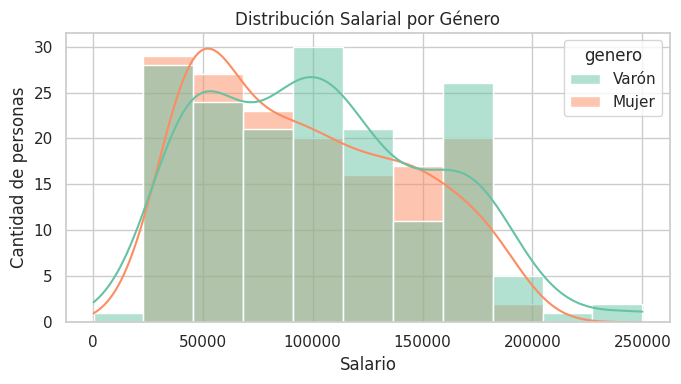

In [8]:
sns.set_theme(style="whitegrid", palette="Set2")

plt.figure(figsize=(7, 4))
sns.histplot(data=df_limpio, x='salario', hue='genero', kde=True)
plt.title('Distribución Salarial por Género')
plt.xlabel('Salario')
plt.ylabel('Cantidad de personas')
plt.tight_layout()
plt.savefig('fig1_distribucion.png', bbox_inches='tight')
plt.show()

**Interpretación:** El gráfico permite observar visualmente si las distribuciones salariales de varones y mujeres se concentran en rangos similares o diferentes. La diferencia entre las distribuciones debe analizarse junto con los salarios promedio y con las demás variables del dataset, ya que el género no es la única característica que puede estar asociada al salario.

### 7.2 Salario según nivel educativo y género

**Pregunta:** ¿Las diferencias salariales se mantienen al comparar distintos niveles educativos?

Se evidencia que los profesionales con PhD presentan las medianas salariales más elevadas, mientras que en el nivel Master's se observa la mayor dispersión y brecha entre géneros.

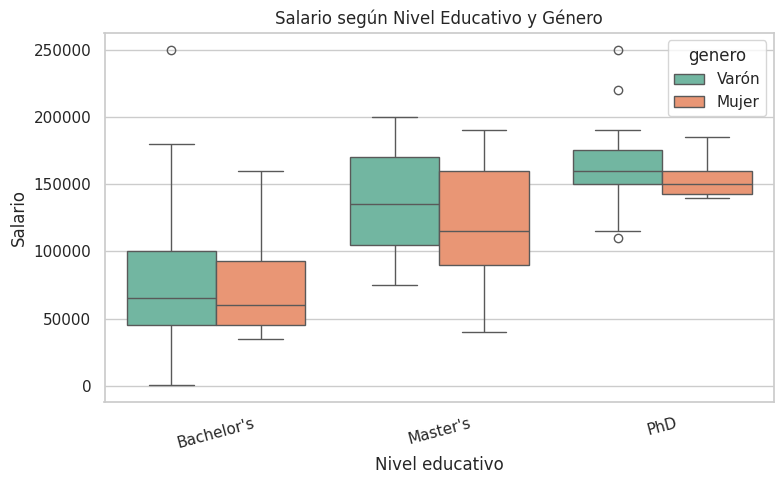

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_limpio,
    x='nivel_educativo',
    y='salario',
    hue='genero'
)
plt.title('Salario según Nivel Educativo y Género')
plt.xlabel('Nivel educativo')
plt.ylabel('Salario')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('fig2_boxplot.png', bbox_inches='tight')
plt.show()

**Interpretación:** Este gráfico permite evaluar si el nivel educativo está asociado con diferencias en los salarios y si, dentro de un mismo nivel educativo, se observan diferencias entre varones y mujeres. También permite identificar diferencias en la dispersión de los salarios entre las categorías educativas.

### 7.3 Relación entre experiencia y salario

**Pregunta:** ¿Existe una relación entre los años de experiencia y el salario?

Los puntos muestran una clara tendencia ascendente, confirmando que a mayor cantidad de años de experiencia, el nivel de salario aumenta de forma proporciona

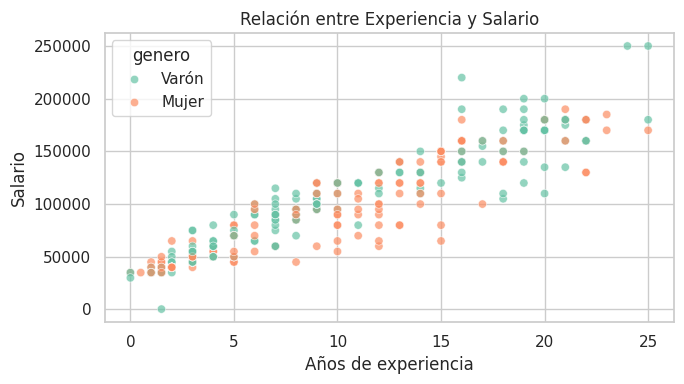

In [10]:
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df_limpio,
    x='experiencia_anios',
    y='salario',
    hue='genero',
    alpha=0.7
)
plt.title('Relación entre Experiencia y Salario')
plt.xlabel('Años de experiencia')
plt.ylabel('Salario')
plt.tight_layout()
plt.savefig('fig3_scatter.png', bbox_inches='tight')
plt.show()

**Interpretación:** La distribución de los puntos permite evaluar si existe una tendencia entre experiencia y salario. Una tendencia ascendente indicaría que, en general, los salarios aumentan a medida que aumenta la experiencia. La dispersión de los puntos también permite observar que la experiencia, aunque pueda estar relacionada con el salario, no explica por sí sola todas las diferencias salariales.

### 7.4 Matriz de correlación

**Pregunta:** ¿Qué relación presentan las variables numéricas entre sí?

Se aprecia una correlación positiva muy fuerte entre las variables numéricas, confirmando el impacto directo de la experiencia en el ingreso.

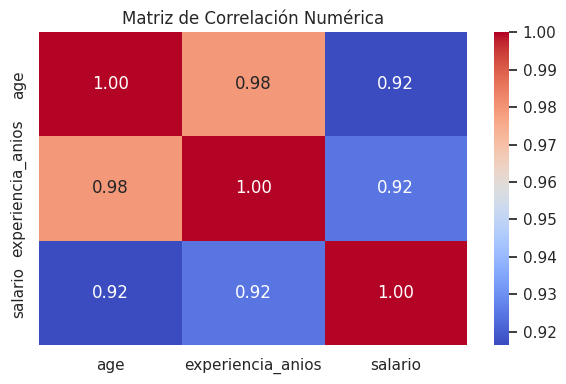

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_limpio.select_dtypes(include=[np.number]).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Matriz de Correlación Numérica')
plt.tight_layout()
plt.savefig('fig4_heatmap.png', bbox_inches='tight')
plt.show()

**Interpretación:** La matriz permite identificar qué variables numéricas presentan las asociaciones lineales más importantes con el salario. Estas correlaciones sirven como punto de partida para el análisis, pero no permiten afirmar causalidad.

## 8. Conclusiones

A partir del análisis realizado se pueden responder las preguntas planteadas inicialmente.

En primer lugar, se compara el salario promedio de varones y mujeres y se cuantifica la diferencia mediante la brecha salarial observada.

En segundo lugar, el análisis por nivel educativo permite evaluar si las diferencias salariales se mantienen cuando se consideran distintos niveles de formación.

En tercer lugar, la relación entre experiencia y salario permite observar si existe una tendencia de crecimiento salarial asociada a los años de experiencia.

Finalmente, la matriz de correlación permite complementar el análisis identificando relaciones entre las variables numéricas.

**Importante:** las diferencias observadas en los salarios no deben atribuirse automáticamente a una única variable. Este análisis es descriptivo y muestra asociaciones presentes en el dataset; no permite establecer relaciones causales.

In [12]:
print("=== CONCLUSIÓN CUANTITATIVA ===")
print(f"Salario promedio de varones: ${prom_varon:,.2f}")
print(f"Salario promedio de mujeres: ${prom_mujer:,.2f}")
print(f"Brecha salarial observada: {brecha_pct:.2f}%")

if brecha_pct > 0:
    print("En el dataset analizado, el salario promedio de los varones es superior al de las mujeres.")
elif brecha_pct < 0:
    print("En el dataset analizado, el salario promedio de las mujeres es superior al de los varones.")
else:
    print("En el dataset analizado, los salarios promedio de ambos grupos son iguales.")

print("\nLa diferencia observada es descriptiva y no implica por sí sola una relación causal con el género.")

=== CONCLUSIÓN CUANTITATIVA ===
Salario promedio de varones: $103,472.65
Salario promedio de mujeres: $96,136.36
Brecha salarial observada: 7.09%
En el dataset analizado, el salario promedio de los varones es superior al de las mujeres.

La diferencia observada es descriptiva y no implica por sí sola una relación causal con el género.


## 9. Exportación del dataset procesado

Finalmente, se guarda una copia del dataset limpio para conservar el resultado del proceso de preparación y permitir su reutilización en futuros análisis.

In [13]:
df_limpio.to_csv('processed_salary_data.csv', index=False)
print("Dataset limpio exportado correctamente como 'processed_salary_data.csv'.")

Dataset limpio exportado correctamente como 'processed_salary_data.csv'.
